In [1]:
import seaborn as sns 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\dell\Downloads\student-mat.csv')
df.head(3)

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


In [14]:
num_cols = df.select_dtypes(include=['str','string']).columns
print(list(num_cols),end='')

['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job', 'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class', 'extra_curr_activities', 'nursery', 'Interested_in_higher_edu', 'internet_access', 'romantic_relationship']

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in num_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   school                    395 non-null    int64
 1   sex                       395 non-null    int64
 2   age                       395 non-null    int64
 3   address                   395 non-null    int64
 4   famsize                   395 non-null    int64
 5   Parrent_status            395 non-null    int64
 6   Mother_edu                395 non-null    int64
 7   Father_edu                395 non-null    int64
 8   Mother_job                395 non-null    int64
 9   Father_job                395 non-null    int64
 10  reason_to_chose_school    395 non-null    int64
 11  guardian                  395 non-null    int64
 12  traveltime                395 non-null    int64
 13  weekly_studytime          395 non-null    int64
 14  failures                  395 non-null    int64
 15  

In [18]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=4,n_init=10)
df['cluster'] = kmean.fit_predict(df)
df.head()


,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3,cluster
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,2
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,2
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,0
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,2


In [19]:
df.cluster.unique()

array([2, 0, 1, 3], dtype=int32)

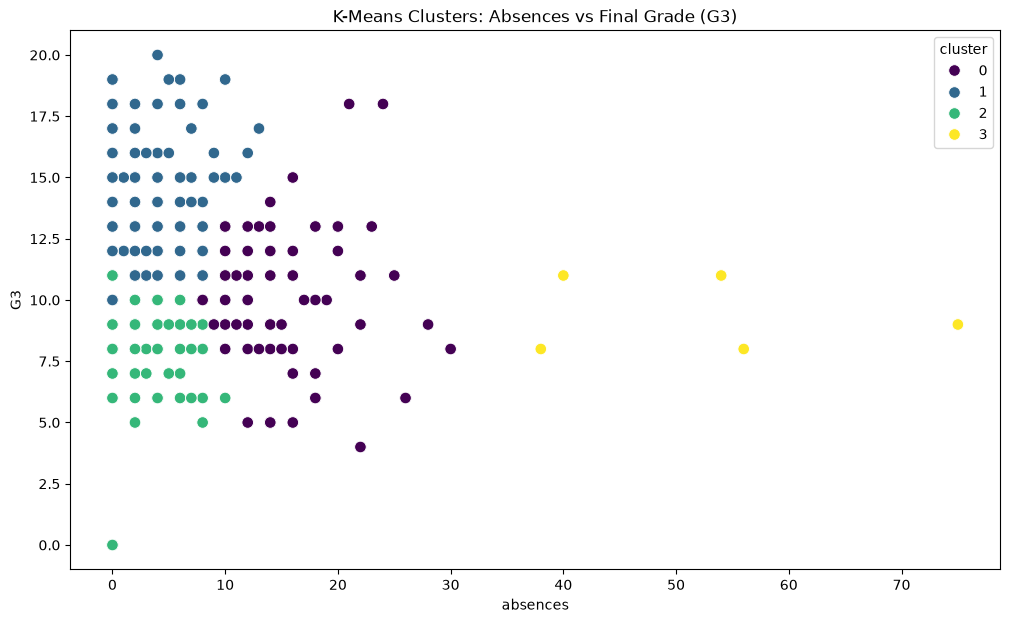

In [20]:
plt.figure(figsize=(12,7))
sns.scatterplot(x='absences', y='G3', hue='cluster', data=df, palette='viridis', s=70)
plt.title('K-Means Clusters: Absences vs Final Grade (G3)')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_2624\2467879339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='G3', data=df, palette='viridis')


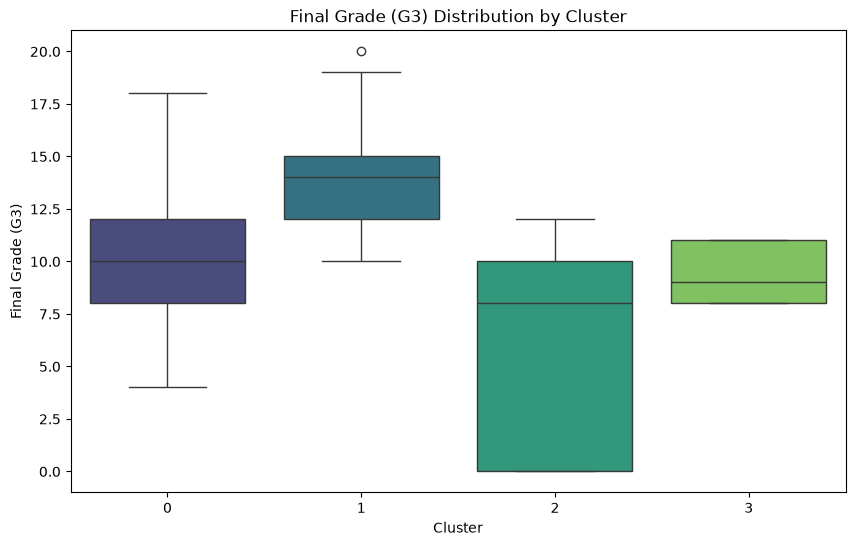

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='G3', data=df, palette='viridis')
plt.title('Final Grade (G3) Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Final Grade (G3)')
plt.show()

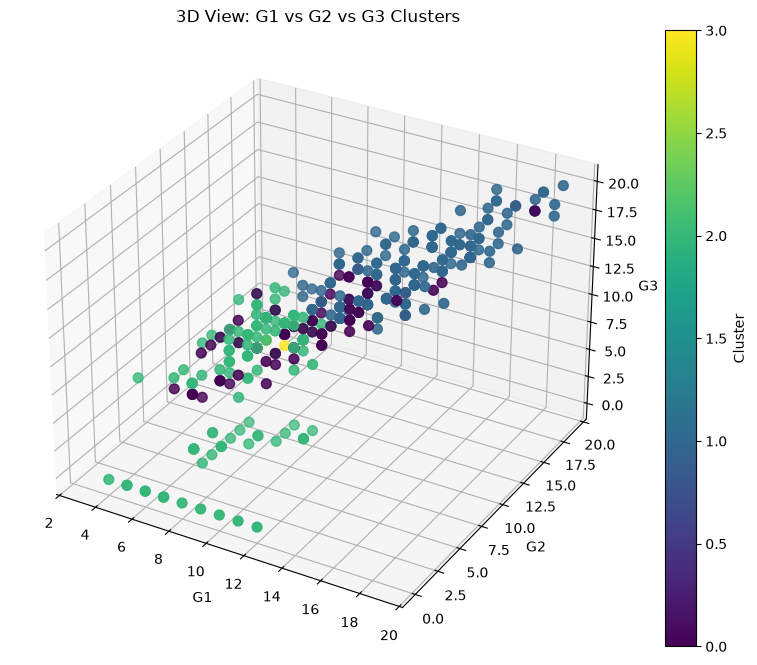

In [22]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['G1'], df['G2'], df['G3'], c=df['cluster'], cmap='viridis', s=50)
ax.set_xlabel('G1')
ax.set_ylabel('G2')
ax.set_zlabel('G3')
plt.title('3D View: G1 vs G2 vs G3 Clusters')
plt.colorbar(scatter, label='Cluster')
plt.show()

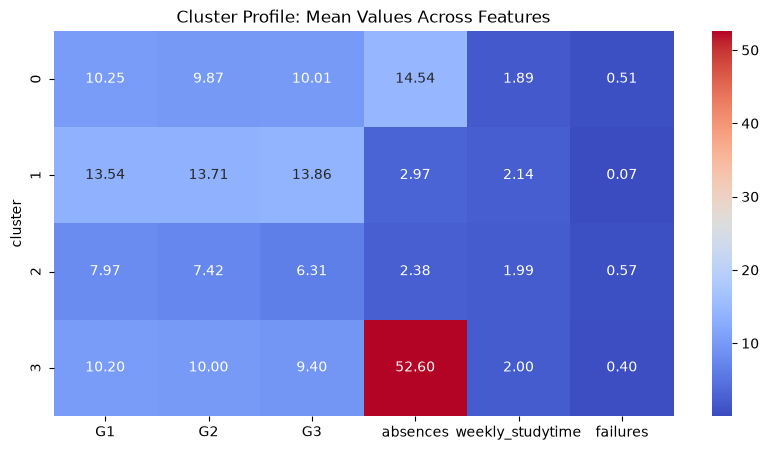

In [23]:
cluster_summary = df.groupby('cluster')[['G1', 'G2', 'G3', 'absences', 'weekly_studytime', 'failures']].mean()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cluster Profile: Mean Values Across Features')
plt.show()

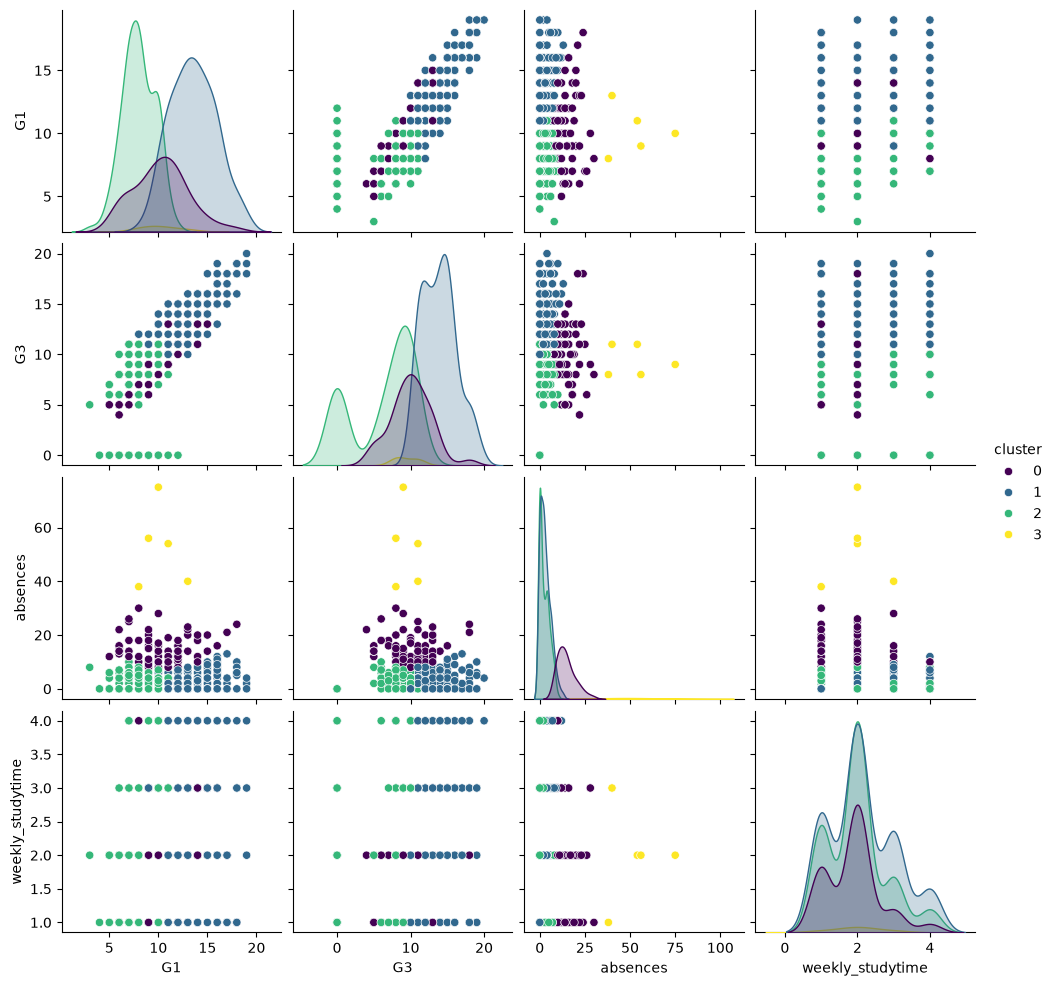

In [24]:
sns.pairplot(df[['G1', 'G3', 'absences', 'weekly_studytime', 'cluster']], hue='cluster', palette='viridis')
plt.show()

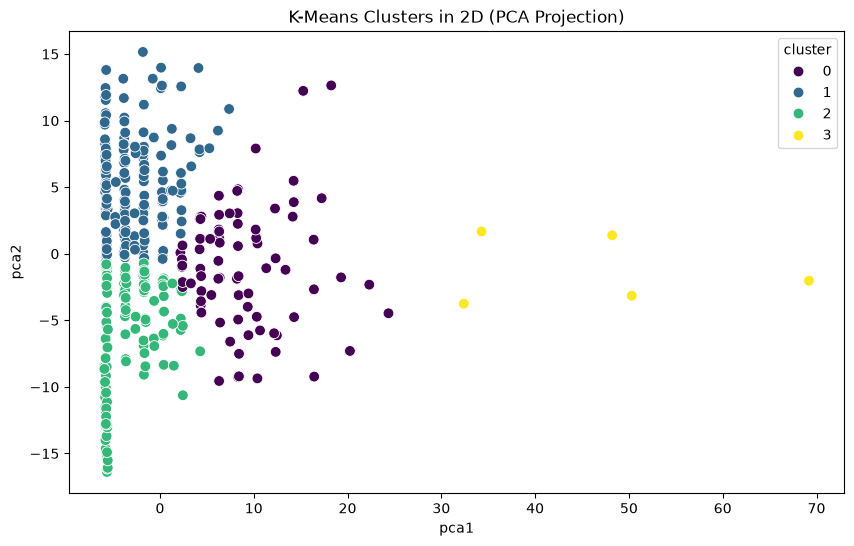

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(df.drop('cluster', axis=1))

df['pca1'] = pca_features[:, 0]
df['pca2'] = pca_features[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='viridis', s=60)
plt.title('K-Means Clusters in 2D (PCA Projection)')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_2624\507937629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='G3', data=df, palette='viridis', inner='quartile')


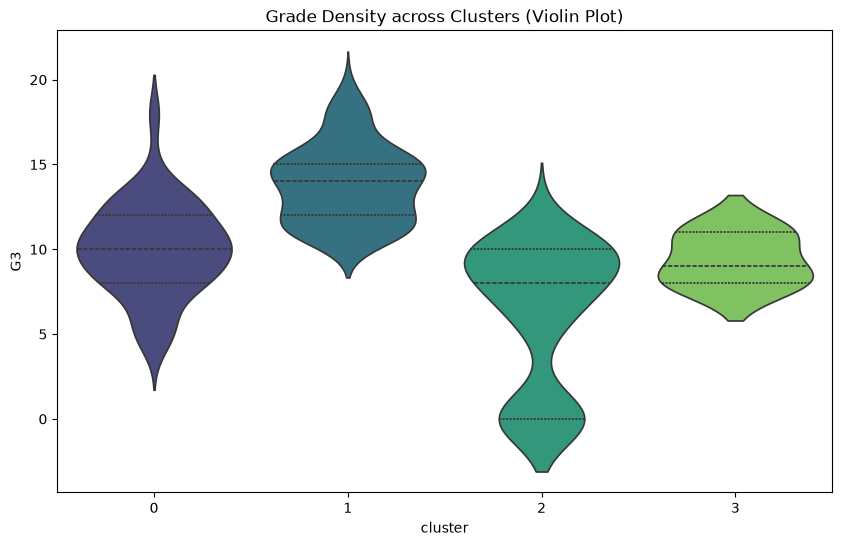

In [26]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='cluster', y='G3', data=df, palette='viridis', inner='quartile')
plt.title('Grade Density across Clusters (Violin Plot)')
plt.show()

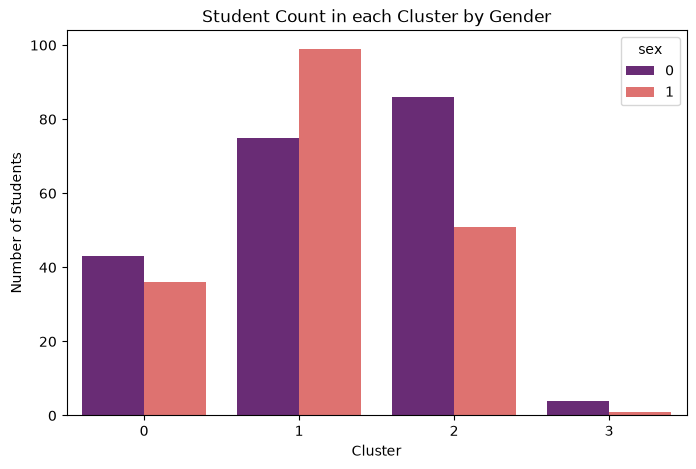

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x='cluster', hue='sex', data=df, palette='magma')
plt.title('Student Count in each Cluster by Gender')
plt.xlabel('Cluster')
plt.ylabel('Number of Students')
plt.show()

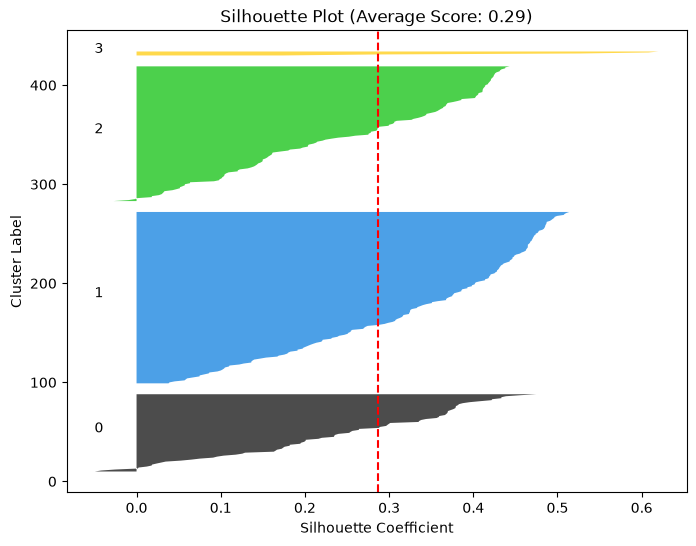

In [28]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

features = df.drop(columns=['cluster', 'pca1', 'pca2'], errors='ignore')
cluster_labels = df['cluster']
silhouette_avg = silhouette_score(features, cluster_labels)
sample_silhouette_values = silhouette_samples(features, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(4):
    ith_cluster_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 4)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_title(f"Silhouette Plot (Average Score: {silhouette_avg:.2f})")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster Label")
plt.show()